In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, r2_score
from sklearn.linear_model import LogisticRegression, Ridge, Lasso, ElasticNet, RidgeClassifier
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.datasets import make_classification, fetch_openml, load_diabetes
from sklearn.preprocessing import PolynomialFeatures
import warnings
warnings.filterwarnings('ignore')

1. Повторите диагностику модели классификации синтетических данных с использованием других метрик эффективности - precision, recall, F1. Как изменились результаты?

In [ ]:
# Генерация синтетических данных
X, y = make_classification(n_samples=10000, n_features=500,
                           n_informative=50, n_repeated=0,
                           class_sep=1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.25,
                                                    random_state=3)

# Логистическая регрессия
lr = LogisticRegression(max_iter=1000).fit(X_train, y_train)
y_train_pred = lr.predict(X_train)
y_test_pred = lr.predict(X_test)

print("\n=== Логистическая регрессия (без регуляризации) ===")
print(f"Train Precision: {precision_score(y_train, y_train_pred):.4f}")
print(f"Test Precision: {precision_score(y_test, y_test_pred):.4f}")
print(f"Train Recall: {recall_score(y_train, y_train_pred):.4f}")
print(f"Test Recall: {recall_score(y_test, y_test_pred):.4f}")
print(f"Train F1: {f1_score(y_train, y_train_pred):.4f}")
print(f"Test F1: {f1_score(y_test, y_test_pred):.4f}")

# Сильно регуляризованная модель
lr_reg = RidgeClassifier(alpha=1000000).fit(X_train, y_train)
y_train_pred_reg = lr_reg.predict(X_train)
y_test_pred_reg = lr_reg.predict(X_test)

print("\n=== Сильно регуляризованная модель (Ridge alpha=1000000) ===")
print(f"Train Precision: {precision_score(y_train, y_train_pred_reg):.4f}")
print(f"Test Precision: {precision_score(y_test, y_test_pred_reg):.4f}")
print(f"Train Recall: {recall_score(y_train, y_train_pred_reg):.4f}")
print(f"Test Recall: {recall_score(y_test, y_test_pred_reg):.4f}")
print(f"Train F1: {f1_score(y_train, y_train_pred_reg):.4f}")
print(f"Test F1: {f1_score(y_test, y_test_pred_reg):.4f}")

# Оптимальная модель
lr_opt = RidgeClassifier(alpha=26500).fit(X_train, y_train)
y_train_pred_opt = lr_opt.predict(X_train)
y_test_pred_opt = lr_opt.predict(X_test)

print("\n=== Оптимальная модель (Ridge alpha=26500) ===")
print(f"Train Precision: {precision_score(y_train, y_train_pred_opt):.4f}")
print(f"Test Precision: {precision_score(y_test, y_test_pred_opt):.4f}")
print(f"Train Recall: {recall_score(y_train, y_train_pred_opt):.4f}")
print(f"Test Recall: {recall_score(y_test, y_test_pred_opt):.4f}")
print(f"Train F1: {f1_score(y_train, y_train_pred_opt):.4f}")
print(f"Test F1: {f1_score(y_test, y_test_pred_opt):.4f}")


=== Логистическая регрессия (без регуляризации) ===
Train Precision: 0.8337
Test Precision: 0.8069
Train Recall: 0.8515
Test Recall: 0.8056
Train F1: 0.8425
Test F1: 0.8062

=== Сильно регуляризованная модель (Ridge alpha=1000000) ===
Train Precision: 0.7683
Test Precision: 0.7678
Train Recall: 0.7780
Test Recall: 0.7801
Train F1: 0.7731
Test F1: 0.7739

=== Оптимальная модель (Ridge alpha=26500) ===
Train Precision: 0.8174
Test Precision: 0.8123
Train Recall: 0.8513
Test Recall: 0.8414
Train F1: 0.8340
Test F1: 0.8266


2. Повторите диагностику модели регрессии с использованием других видов моделей:
- метода опорных векторов (исследуйте влияние параметра С на недо-и переобучение)
- метода ближайших соседей (исследуйте влияние количества соседей)
- метода решающих деревьев (гиперпараметры по вашему выбору)

Размер датасета diabetes: (442, 10)
Названия признаков: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

--- SVR с разными C ---
C=0.01: Train R2=-0.0248, Test R2=-0.0367
C=0.1: Train R2=-0.0061, Test R2=-0.0213
C=1: Train R2=0.1737, Test R2=0.1384
C=10: Train R2=0.5908, Test R2=0.3634
C=100: Train R2=0.7243, Test R2=0.2149
C=1000: Train R2=0.8775, Test R2=0.0436

--- KNN с разным количеством соседей ---
n_neighbors=1: Train R2=1.0000, Test R2=-0.5549
n_neighbors=3: Train R2=0.7078, Test R2=0.1475
n_neighbors=5: Train R2=0.6239, Test R2=0.1891
n_neighbors=10: Train R2=0.5673, Test R2=0.2645
n_neighbors=20: Train R2=0.5442, Test R2=0.3630
n_neighbors=50: Train R2=0.4843, Test R2=0.3590

--- Decision Tree с разной глубиной ---
max_depth=1: Train R2=0.3219, Test R2=0.0736
max_depth=3: Train R2=0.5775, Test R2=0.0868
max_depth=5: Train R2=0.7158, Test R2=0.0700
max_depth=10: Train R2=0.9447, Test R2=-0.0780
max_depth=15: Train R2=0.9995, Test R2=-0.1260
max_depth=20: Train 

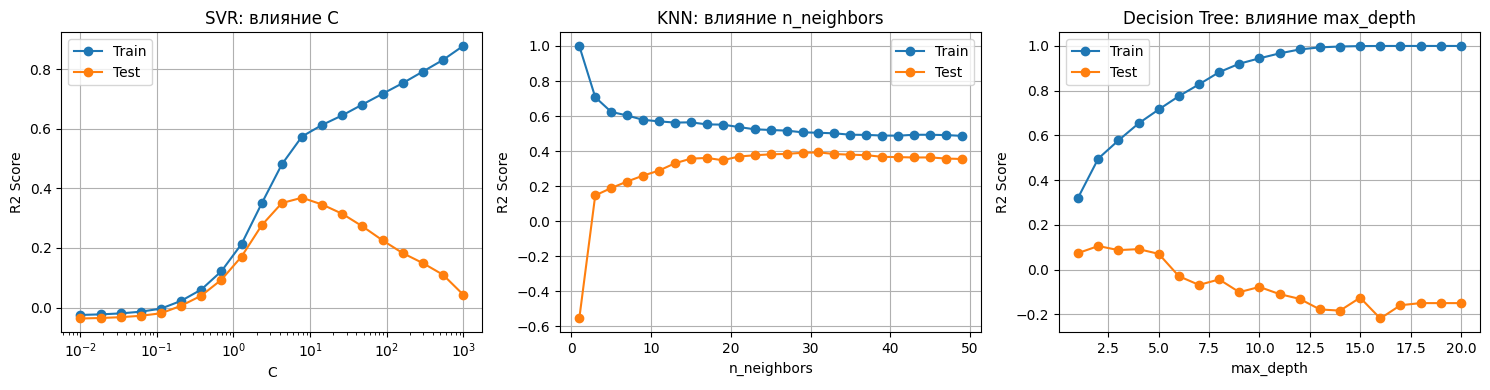


Оптимальные параметры:
SVR: C=7.85, Test R2=0.3684
KNN: n_neighbors=31, Test R2=0.3929
Decision Tree: max_depth=2, Test R2=0.1050


In [ ]:
# Загрузка датасета diabetes для регрессии
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target
print(f"Размер датасета diabetes: {X.shape}")
print(f"Названия признаков: {diabetes.feature_names}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

# 2.1 Метод опорных векторов (влияние параметра C)
print("\n--- SVR с разными C ---")
C_values = [0.01, 0.1, 1, 10, 100, 1000]
for C in C_values:
    svr = SVR(C=C).fit(X_train, y_train)
    print(f"C={C}: Train R2={svr.score(X_train, y_train):.4f}, Test R2={svr.score(X_test, y_test):.4f}")

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
trains_svr = []
tests_svr = []
C_range = np.logspace(-2, 3, 20)
for C in C_range:
    svr = SVR(C=C).fit(X_train, y_train)
    trains_svr.append(svr.score(X_train, y_train))
    tests_svr.append(svr.score(X_test, y_test))
plt.plot(C_range, trains_svr, 'o-', label='Train')
plt.plot(C_range, tests_svr, 'o-', label='Test')
plt.xscale('log')
plt.title('SVR: влияние C')
plt.xlabel('C')
plt.ylabel('R2 Score')
plt.legend()
plt.grid(True)

# 2.2 Метод ближайших соседей (влияние количества соседей)
print("\n--- KNN с разным количеством соседей ---")
n_neighbors_values = [1, 3, 5, 10, 20, 50]
for n in n_neighbors_values:
    knn = KNeighborsRegressor(n_neighbors=n).fit(X_train, y_train)
    print(f"n_neighbors={n}: Train R2={knn.score(X_train, y_train):.4f}, Test R2={knn.score(X_test, y_test):.4f}")

plt.subplot(1, 3, 2)
trains_knn = []
tests_knn = []
n_range = range(1, 51, 2)
for n in n_range:
    knn = KNeighborsRegressor(n_neighbors=n).fit(X_train, y_train)
    trains_knn.append(knn.score(X_train, y_train))
    tests_knn.append(knn.score(X_test, y_test))
plt.plot(n_range, trains_knn, 'o-', label='Train')
plt.plot(n_range, tests_knn, 'o-', label='Test')
plt.title('KNN: влияние n_neighbors')
plt.xlabel('n_neighbors')
plt.ylabel('R2 Score')
plt.legend()
plt.grid(True)

# 2.3 Решающие деревья (влияние глубины)
print("\n--- Decision Tree с разной глубиной ---")
depth_values = [1, 3, 5, 10, 15, 20]
for depth in depth_values:
    dt = DecisionTreeRegressor(max_depth=depth, random_state=1).fit(X_train, y_train)
    print(f"max_depth={depth}: Train R2={dt.score(X_train, y_train):.4f}, Test R2={dt.score(X_test, y_test):.4f}")

plt.subplot(1, 3, 3)
trains_dt = []
tests_dt = []
depth_range = range(1, 21)
for depth in depth_range:
    dt = DecisionTreeRegressor(max_depth=depth, random_state=1).fit(X_train, y_train)
    trains_dt.append(dt.score(X_train, y_train))
    tests_dt.append(dt.score(X_test, y_test))
plt.plot(depth_range, trains_dt, 'o-', label='Train')
plt.plot(depth_range, tests_dt, 'o-', label='Test')
plt.title('Decision Tree: влияние max_depth')
plt.xlabel('max_depth')
plt.ylabel('R2 Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Анализ оптимальных параметров
best_c_idx = np.argmax(tests_svr)
best_c = C_range[best_c_idx]
best_k_idx = np.argmax(tests_knn)
best_k = n_range[best_k_idx]
best_depth_idx = np.argmax(tests_dt)
best_depth = depth_range[best_depth_idx]

print(f"\nОптимальные параметры:")
print(f"SVR: C={best_c:.2f}, Test R2={tests_svr[best_c_idx]:.4f}")
print(f"KNN: n_neighbors={best_k}, Test R2={tests_knn[best_k_idx]:.4f}")
print(f"Decision Tree: max_depth={best_depth}, Test R2={tests_dt[best_depth_idx]:.4f}")

3. Дополните анализ датасета Бостон исследованием модели лассо - постройте кривые обучения для переобученной, недообученной и качественной модели, найдите оптимальное значение параметра регуляризации в модели лассо.

Переобученная (alpha=0.0001): Train R2=0.5554, Test R2=0.3593
Недообученная (alpha=1.0): Train R2=0.4141, Test R2=0.2782

Оптимальная модель (alpha=0.0001): Train R2=0.5554, Test R2=0.3593


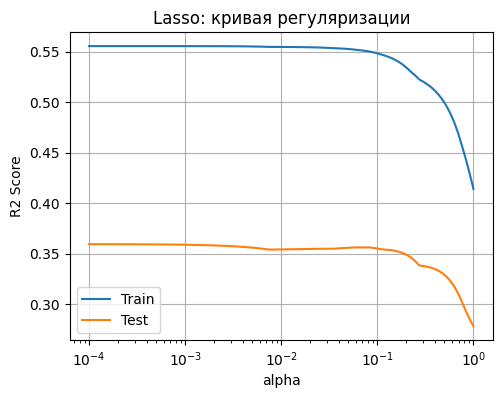

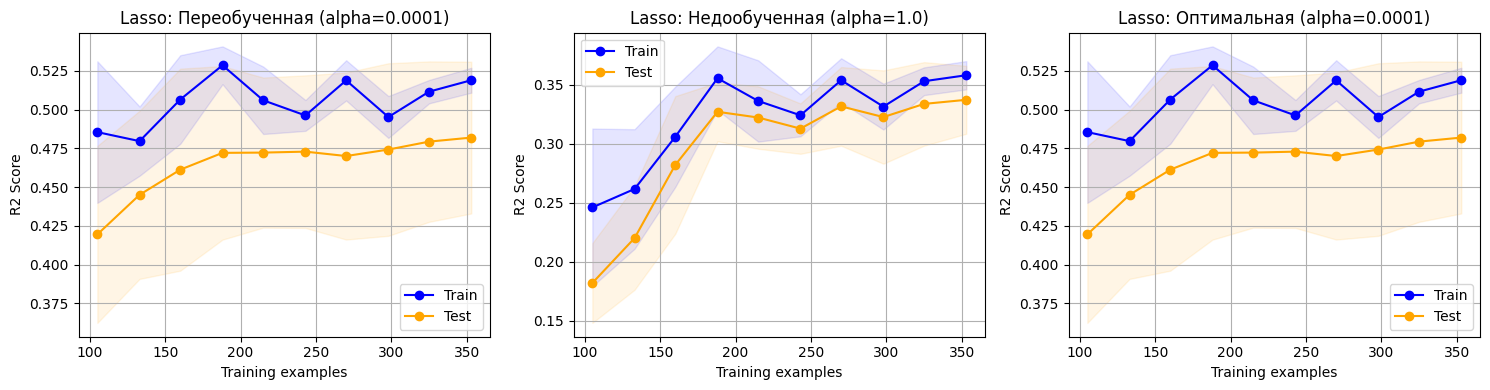

In [ ]:
# Переобученная модель (маленькая регуляризация)
lasso_over = Lasso(alpha=0.0001, max_iter=10000).fit(X_train, y_train)
print(f"Переобученная (alpha=0.0001): Train R2={lasso_over.score(X_train, y_train):.4f}, Test R2={lasso_over.score(X_test, y_test):.4f}")

# Недообученная модель (большая регуляризация)
lasso_under = Lasso(alpha=1.0, max_iter=10000).fit(X_train, y_train)
print(f"Недообученная (alpha=1.0): Train R2={lasso_under.score(X_train, y_train):.4f}, Test R2={lasso_under.score(X_test, y_test):.4f}")

# Поиск оптимального alpha
trains_lasso = []
tests_lasso = []
alphas = np.logspace(-4, 0, 100)

for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000).fit(X_train, y_train)
    trains_lasso.append(lasso.score(X_train, y_train))
    tests_lasso.append(lasso.score(X_test, y_test))

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(alphas, trains_lasso, label='Train')
plt.plot(alphas, tests_lasso, label='Test')
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('R2 Score')
plt.title('Lasso: кривая регуляризации')
plt.legend()
plt.grid(True)

# Оптимальное значение
optimal_idx = np.argmax(tests_lasso)
optimal_alpha = alphas[optimal_idx]
lasso_opt = Lasso(alpha=optimal_alpha, max_iter=10000).fit(X_train, y_train)

print(f"\nОптимальная модель (alpha={optimal_alpha:.4f}): Train R2={lasso_opt.score(X_train, y_train):.4f}, Test R2={lasso_opt.score(X_test, y_test):.4f}")

# Кривые обучения для трех моделей
def plot_learning_curve(estimator, title, X, y, ax):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=5, n_jobs=-1,
        train_sizes=np.linspace(0.3, 1.0, 10), scoring='r2')

    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
    ax.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')
    ax.plot(train_sizes, train_mean, 'o-', color='blue', label='Train')
    ax.plot(train_sizes, test_mean, 'o-', color='orange', label='Test')
    ax.set_title(title)
    ax.set_xlabel('Training examples')
    ax.set_ylabel('R2 Score')
    ax.legend(loc='best')
    ax.grid(True)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

plot_learning_curve(Lasso(alpha=0.0001, max_iter=10000), 'Lasso: Переобученная (alpha=0.0001)', X, y, axes[0])
plot_learning_curve(Lasso(alpha=1.0, max_iter=10000), 'Lasso: Недообученная (alpha=1.0)', X, y, axes[1])
plot_learning_curve(Lasso(alpha=optimal_alpha, max_iter=10000), f'Lasso: Оптимальная (alpha={optimal_alpha:.4f})', X, y, axes[2])

plt.tight_layout()
plt.show()

4. В одном из двух первых примеров используйте модель ElasticNet и исследуйте влияние сразу двух параметров регуляризации на эффективность модели.

l1_ratio=0.1: оптимальный alpha=0.0010, Test R2=0.3803
l1_ratio=0.5: оптимальный alpha=0.0021, Test R2=0.3803
l1_ratio=0.9: оптимальный alpha=0.0087, Test R2=0.3798


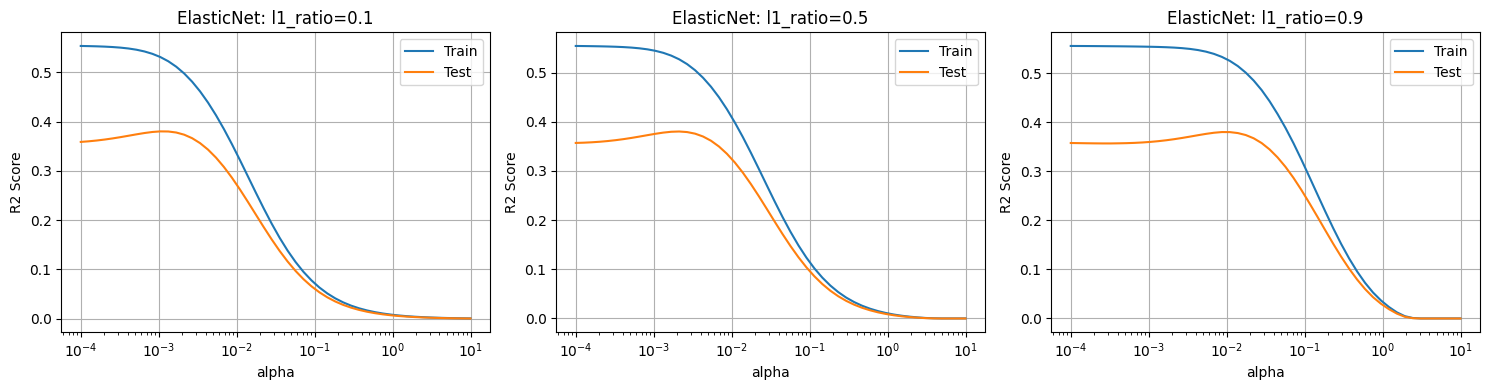


=== Сетка параметров ElasticNet ===
l1_ratio=0.1, alpha=0.0001: Train=0.5538, Test=0.3589
l1_ratio=0.1, alpha=0.001: Train=0.5328, Test=0.3801
l1_ratio=0.1, alpha=0.01: Train=0.3354, Test=0.2723
l1_ratio=0.1, alpha=0.1: Train=0.0716, Test=0.0605
l1_ratio=0.1, alpha=1.0: Train=0.0076, Test=0.0064
l1_ratio=0.3, alpha=0.0001: Train=0.5541, Test=0.3579
l1_ratio=0.3, alpha=0.001: Train=0.5393, Test=0.3786
l1_ratio=0.3, alpha=0.01: Train=0.3687, Test=0.2965
l1_ratio=0.3, alpha=0.1: Train=0.0879, Test=0.0741
l1_ratio=0.3, alpha=1.0: Train=0.0086, Test=0.0071
l1_ratio=0.5, alpha=0.0001: Train=0.5544, Test=0.3571
l1_ratio=0.5, alpha=0.001: Train=0.5452, Test=0.3751
l1_ratio=0.5, alpha=0.01: Train=0.4098, Test=0.3247
l1_ratio=0.5, alpha=0.1: Train=0.1146, Test=0.0963
l1_ratio=0.5, alpha=1.0: Train=0.0103, Test=0.0085
l1_ratio=0.7, alpha=0.0001: Train=0.5547, Test=0.3566
l1_ratio=0.7, alpha=0.001: Train=0.5502, Test=0.3690
l1_ratio=0.7, alpha=0.01: Train=0.4622, Test=0.3565
l1_ratio=0.7, alpha=0

In [ ]:
# Фиксируем l1_ratio и меняем alpha
l1_ratios = [0.1, 0.5, 0.9]
alphas = np.logspace(-4, 1, 50)

plt.figure(figsize=(15, 4))

for i, l1_ratio in enumerate(l1_ratios):
    plt.subplot(1, 3, i+1)
    trains_en = []
    tests_en = []

    for alpha in alphas:
        en = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=42, max_iter=10000).fit(X_train, y_train)
        trains_en.append(en.score(X_train, y_train))
        tests_en.append(en.score(X_test, y_test))

    plt.plot(alphas, trains_en, label='Train')
    plt.plot(alphas, tests_en, label='Test')
    plt.xscale('log')
    plt.title(f'ElasticNet: l1_ratio={l1_ratio}')
    plt.xlabel('alpha')
    plt.ylabel('R2 Score')
    plt.legend()
    plt.grid(True)

    # Находим оптимальный alpha для данного l1_ratio
    opt_idx = np.argmax(tests_en)
    print(f"l1_ratio={l1_ratio}: оптимальный alpha={alphas[opt_idx]:.4f}, Test R2={tests_en[opt_idx]:.4f}")

plt.tight_layout()
plt.show()

# Сетка параметров
print("\n=== Сетка параметров ElasticNet ===")
l1_ratios_grid = [0.1, 0.3, 0.5, 0.7, 0.9]
alphas_grid = [0.0001, 0.001, 0.01, 0.1, 1.0]

best_test = -np.inf
best_params = None

for l1 in l1_ratios_grid:
    for alpha in alphas_grid:
        en = ElasticNet(alpha=alpha, l1_ratio=l1, random_state=42, max_iter=10000).fit(X_train, y_train)
        train_score = en.score(X_train, y_train)
        test_score = en.score(X_test, y_test)
        print(f"l1_ratio={l1}, alpha={alpha}: Train={train_score:.4f}, Test={test_score:.4f}")

        if test_score > best_test:
            best_test = test_score
            best_params = (l1, alpha)

print(f"\nЛучшая модель: l1_ratio={best_params[0]}, alpha={best_params[1]}, Test R2={best_test:.4f}")

5. Дополните анализ дерева решений из третьего примера: постройте кривые регуляризации для полного датасета, найдите оптимальную глубину дерева и оцените качество такой модели на всем датасете. Повторите данный анализ используя в качестве метрики эффективности F1.

Размер обучающей выборки: (614, 8)
Размер тестовой выборки: (154, 8)
Распределение классов:
Outcome
0    500
1    268
Name: count, dtype: int64

Оптимальная глубина по F1: 5
Оптимальная глубина по Accuracy: 5

Модель с оптимальной глубиной 5 (по F1):
Train Accuracy: 0.8420
Test Accuracy: 0.7987
Train F1: 0.7467
Test F1: 0.6931

Модель без ограничения глубины:
Train F1: 1.0000
Test F1: 0.6379
Разрыв: 0.3621


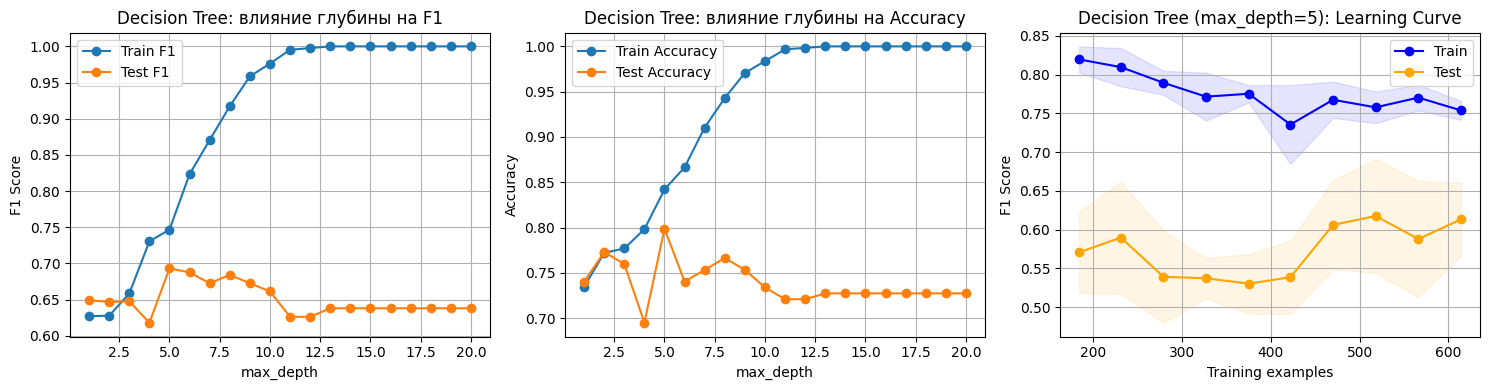

In [ ]:
# Загрузка полного датасета diabetes для классификации
df = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML4.3%20diagnostics/diabetes.csv')
target = "Outcome"
y = df[target]
X = df.drop(target, axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"Распределение классов:\n{y.value_counts()}")

# Поиск оптимальной глубины по F1
depths = range(1, 21)
trains_f1 = []
tests_f1 = []
trains_acc = []
tests_acc = []

for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=1).fit(X_train, y_train)
    y_train_pred = dt.predict(X_train)
    y_test_pred = dt.predict(X_test)
    trains_f1.append(f1_score(y_train, y_train_pred))
    tests_f1.append(f1_score(y_test, y_test_pred))
    trains_acc.append(accuracy_score(y_train, y_train_pred))
    tests_acc.append(accuracy_score(y_test, y_test_pred))

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.plot(depths, trains_f1, 'o-', label='Train F1')
plt.plot(depths, tests_f1, 'o-', label='Test F1')
plt.xlabel('max_depth')
plt.ylabel('F1 Score')
plt.title('Decision Tree: влияние глубины на F1')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(depths, trains_acc, 'o-', label='Train Accuracy')
plt.plot(depths, tests_acc, 'o-', label='Test Accuracy')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree: влияние глубины на Accuracy')
plt.legend()
plt.grid(True)

# Оптимальная глубина по F1
optimal_depth_f1 = depths[np.argmax(tests_f1)]
optimal_depth_acc = depths[np.argmax(tests_acc)]

print(f"\nОптимальная глубина по F1: {optimal_depth_f1}")
print(f"Оптимальная глубина по Accuracy: {optimal_depth_acc}")

# Оценка модели с оптимальной глубиной по F1
dt_opt = DecisionTreeClassifier(max_depth=optimal_depth_f1, random_state=1).fit(X_train, y_train)
y_train_pred_opt = dt_opt.predict(X_train)
y_test_pred_opt = dt_opt.predict(X_test)

print(f"\nМодель с оптимальной глубиной {optimal_depth_f1} (по F1):")
print(f"Train Accuracy: {accuracy_score(y_train, y_train_pred_opt):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred_opt):.4f}")
print(f"Train F1: {f1_score(y_train, y_train_pred_opt):.4f}")
print(f"Test F1: {f1_score(y_test, y_test_pred_opt):.4f}")

# Сравнение с моделью без ограничения глубины
dt_full = DecisionTreeClassifier(random_state=1).fit(X_train, y_train)
y_train_pred_full = dt_full.predict(X_train)
y_test_pred_full = dt_full.predict(X_test)

print(f"\nМодель без ограничения глубины:")
print(f"Train F1: {f1_score(y_train, y_train_pred_full):.4f}")
print(f"Test F1: {f1_score(y_test, y_test_pred_full):.4f}")
print(f"Разрыв: {f1_score(y_train, y_train_pred_full) - f1_score(y_test, y_test_pred_full):.4f}")

# Кривая обучения для оптимальной модели
plt.subplot(1, 3, 3)
train_sizes, train_scores, test_scores = learning_curve(
    DecisionTreeClassifier(max_depth=optimal_depth_f1, random_state=1),
    X, y, cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.3, 1.0, 10),
    scoring='f1'
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Train')
plt.plot(train_sizes, test_mean, 'o-', color='orange', label='Test')
plt.title(f'Decision Tree (max_depth={optimal_depth_f1}): Learning Curve')
plt.xlabel('Training examples')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

6. Повторите анализ на других реальных датасетах из репозитория OpenML:
- phoneme
- banknote-authentication
- delta_ailerons
- mammography
- electricity
- mozilla4
- kropt
- nursery
- volcanoes-b3

In [ ]:
datasets = [
    'phoneme',
    'banknote-authentication',
    'delta_ailerons',
    'mammography',
    'electricity',
    'mozilla4',
    'kropt',
    'nursery',
    'volcanoes-b3'
]

for dataset_name in datasets:
    print(f"\n{'='*50}")
    print(f"Датасет: {dataset_name}")
    print('='*50)

    try:
        # Загрузка данных
        data = fetch_openml(name=dataset_name, parser='auto')
        X = pd.get_dummies(data.data)
        y = data.target

        # Преобразование целевой переменной в числовой формат для классификации
        if y.dtype == 'object' or hasattr(y, 'dtype') and y.dtype == 'object':
            y = pd.factorize(y)[0]
        else:
            y = y.astype(int)

        print(f"Размер данных: {X.shape}")
        print(f"Количество классов: {len(np.unique(y))}")

        # Разделение на обучающую и тестовую выборки
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        # Простая модель (логистическая регрессия)
        lr = LogisticRegression(max_iter=1000).fit(X_train, y_train)
        lr_train = accuracy_score(y_train, lr.predict(X_train))
        lr_test = accuracy_score(y_test, lr.predict(X_test))
        print(f"Logistic Regression - Train: {lr_train:.4f}, Test: {lr_test:.4f}, Разрыв: {lr_train - lr_test:.4f}")

        # Сложная модель (дерево решений без ограничений)
        dt = DecisionTreeClassifier(random_state=1).fit(X_train, y_train)
        dt_train = accuracy_score(y_train, dt.predict(X_train))
        dt_test = accuracy_score(y_test, dt.predict(X_test))
        print(f"Decision Tree (полное) - Train: {dt_train:.4f}, Test: {dt_test:.4f}, Разрыв: {dt_train - dt_test:.4f}")

        # Регуляризованное дерево
        dt_reg = DecisionTreeClassifier(max_depth=5, random_state=1).fit(X_train, y_train)
        dt_reg_train = accuracy_score(y_train, dt_reg.predict(X_train))
        dt_reg_test = accuracy_score(y_test, dt_reg.predict(X_test))
        print(f"Decision Tree (max_depth=5) - Train: {dt_reg_train:.4f}, Test: {dt_reg_test:.4f}, Разрыв: {dt_reg_train - dt_reg_test:.4f}")

        # Определение проблемы
        if lr_train < 0.7:
            print(">>> Проблема: Низкая точность даже на train - возможно НЕДООБУЧЕНИЕ")
        elif dt_train - dt_test > 0.2:
            print(">>> Проблема: Большой разрыв между train и test - возможно ПЕРЕОБУЧЕНИЕ")
        else:
            print(">>> Модели выглядят сбалансированно")

        # Дополнительно: F1-score для несбалансированных данных
        if len(np.unique(y)) == 2:  # бинарная классификация
            lr_f1 = f1_score(y_test, lr.predict(X_test))
            dt_f1 = f1_score(y_test, dt.predict(X_test))
            dt_reg_f1 = f1_score(y_test, dt_reg.predict(X_test))
            print(f"F1 scores - LR: {lr_f1:.4f}, DT: {dt_f1:.4f}, DT_reg: {dt_reg_f1:.4f}")

    except Exception as e:
        print(f"Ошибка при загрузке {dataset_name}: {e}")


Датасет: phoneme
Размер данных: (5404, 5)
Количество классов: 2
Logistic Regression - Train: 0.7486, Test: 0.7558, Разрыв: -0.0072
Decision Tree (полное) - Train: 1.0000, Test: 0.8437, Разрыв: 0.1563
Decision Tree (max_depth=5) - Train: 0.8330, Test: 0.8178, Разрыв: 0.0152
>>> Модели выглядят сбалансированно
F1 scores - LR: 0.8360, DT: 0.8893, DT_reg: 0.8681

Датасет: banknote-authentication
Размер данных: (1372, 4)
Количество классов: 2
Logistic Regression - Train: 0.9918, Test: 0.9855, Разрыв: 0.0063
Decision Tree (полное) - Train: 1.0000, Test: 0.9745, Разрыв: 0.0255
Decision Tree (max_depth=5) - Train: 0.9872, Test: 0.9673, Разрыв: 0.0200
>>> Модели выглядят сбалансированно
F1 scores - LR: 0.9865, DT: 0.9769, DT_reg: 0.9705

Датасет: delta_ailerons
Ошибка при загрузке delta_ailerons: Cannot cast object dtype to int64

Датасет: mammography
Размер данных: (11183, 6)
Количество классов: 2
Logistic Regression - Train: 0.9828, Test: 0.9866, Разрыв: -0.0038
Decision Tree (полное) - Trai